In [ ]:
from pathlib import Path
import datetime as dt
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import dates as md

In [ ]:
PROJPATH = Path().resolve().parent
breakupfpth = PROJPATH / "data/breakupdata/derived/breakupDate_cleaned_selected.csv"
brokenuppth = PROJPATH / "data/DDforecast_2025/broken_up_2025.csv"
combindedpth = PROJPATH / "data/weatherstations/ACIS_combined_DD"
locationprefix = "DD25_combined_"
today = dt.datetime.now().strftime("%Y-%m-%d")
daily_reportpth = PROJPATH / f"data/DDforecast_2026/daily_report_{today}.csv"

In [ ]:
daily_report = pd.read_csv(daily_reportpth)
daily_report

,location,river,forecastdate,most likely breakup in (days),forecasted date,average breakup date,probability of breakup within ± 3 days around forecasted,probability of breakup within 1 or 2 days,probability of breakup within 3-7 days,probability of breakup within week 2 from now,probability of breakup within week 3 from now
0,Buckland,Buckland River,2026-04-14,35,2026-05-18,2026-05-17,0.35,0.0,0.00,0.00,0.02
1,Umiat,Colville River,2026-04-14,43,2026-05-26,2026-05-24,0.37,0.0,0.00,0.00,0.00
2,Colville Village,Colville River,2026-04-14,50,2026-06-02,2026-06-01,0.38,0.0,0.00,0.00,0.00
3,Kobuk,Kobuk River,2026-04-14,33,2026-05-16,2026-05-16,0.41,0.0,0.00,0.00,0.02
4,Shungnak,Kobuk River,2026-04-14,35,2026-05-18,2026-05-17,0.42,0.0,0.00,0.00,0.01
5,Ambler,Kobuk River,2026-04-14,35,2026-05-18,2026-05-18,0.41,0.0,0.00,0.00,0.01
6,Allakaket,Koyukuk River,2026-04-14,29,2026-05-12,2026-05-10,0.43,0.0,0.00,0.00,0.07
7,Bettles,Koyukuk River,2026-04-14,28,2026-05-11,2026-05-10,0.42,0.0,0.00,0.01,0.11
8,Hughes,Koyukuk River,2026-04-14,28,2026-05-11,2026-05-11,0.41,0.0,0.00,0.01,0.10
9,Nikolai,Kuskokwim River,2026-04-14,14,2026-04-27,2026-04-23,0.55,0.0,0.05,0.43,0.45


In [ ]:
breakup = pd.read_csv(breakupfpth, skiprows=3, index_col=0)
breakup

,id,siteID,year,breakup,JulianDay
1894,209,Buckland River at Buckland,1983,1983-05-12,132
1866,210,Buckland River at Buckland,1984,1984-05-23,144
1829,1067,Buckland River at Buckland,1985,1985-05-26,146
1780,211,Buckland River at Buckland,1986,1986-05-30,150
1741,212,Buckland River at Buckland,1987,1987-05-22,142
...,...,...,...,...,...
227,7081,Yukon River nr Emmonak,2021,2021-05-13,133
176,7160,Yukon River nr Emmonak,2022,2022-05-15,135
143,7236,Yukon River nr Emmonak,2023,2023-05-27,147
83,7294,Yukon River nr Emmonak,2024,2023-05-24,144


In [ ]:
siteIDs = breakup.siteID.unique()
testsite = 'Kuskokwim River at Nikolai'
# testsite = 'Tanana River at Nenana'
# testsite = 'Buckland River at Buckland'
testsite = 'Yukon River at Galena'
testdd = pd.read_csv(combindedpth / f"{locationprefix}{testsite.replace(' ', '_')}.csv", skiprows=3)
testdd_melted = testdd.melt(id_vars=['julian_day'], value_vars=testdd.columns[1:], var_name='year', value_name='dd25')
testdd_melted.set_index(['julian_day', 'year'], inplace=True)
testdd_melted

,,dd25
julian_day,year,
60,1980,NaN
61,1980,0.00
62,1980,0.00
63,1980,0.00
64,1980,1.50
...,...,...
178,2026,1680.75
179,2026,1713.63
180,2026,1746.82


In [ ]:
broken_up = pd.read_csv(brokenuppth, index_col=0)
broken_up

,breakup
location,
Yukon River at Dawson,2025-04-30
Yukon River at Eagle,2025-05-01
Yukon River at Circle,2025-05-05
Yukon River at Fort Yukon,2025-05-06
Kuskokwim River at Nikolai,2025-04-22
Kuskokwim River at McGrath,2025-05-03
Yukon River at Galena,2025-05-08
Kuskokwim River at Crooked Creek,2025-04-28
Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
actualbreakup = broken_up.loc[testsite].item()

In [ ]:
breakupdd25 = []
for _, year, JulianDay in  breakup[breakup.siteID==testsite][['year', 'JulianDay']].itertuples():
    breakupdd25.append([year, JulianDay, testdd_melted.loc[(JulianDay, str(year)), 'dd25']])
breakupdd25DF = pd.DataFrame(breakupdd25)
breakupdd25DF.columns = ['year', 'JulianDay', 'DD25']
breakupdd25DF['thedate'] = pd.to_datetime(breakupdd25DF.JulianDay-1, unit='D',
               origin=pd.Timestamp('2026-01-01'))
breakupdd25DF


,year,JulianDay,DD25,thedate
0,1980,131,451.75,2026-05-11
1,1982,140,409.16,2026-05-20
2,1983,130,364.75,2026-05-10
3,1984,140,432.17,2026-05-20
4,1985,143,298.75,2026-05-23
5,1986,140,352.25,2026-05-20
6,1987,136,470.00,2026-05-16
7,1988,128,385.75,2026-05-08
8,1989,127,360.47,2026-05-07
9,1990,128,472.89,2026-05-08


In [ ]:
meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()

In [ ]:
testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
               origin=pd.Timestamp('2026-01-01'))
testdd.set_index('thedate', inplace=True)
testdd['2026-04-01':'2026-05-30']

,julian_day,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
thedate,,,,,,,,,,,,,,,,,,,,,
2026-04-01,91,44.75,124.25,42.75,0.00,87.25,14.50,0.00,74.00,50.75,...,7.67,17.25,174.12,35.75,6.38,15.25,12.00,69.88,32.38,0.00
2026-04-02,92,55.00,127.50,42.75,0.00,94.50,14.50,0.00,77.25,50.75,...,15.50,17.62,183.25,36.00,6.38,15.25,12.00,70.75,38.88,0.00
2026-04-03,93,66.75,129.00,42.75,0.00,102.25,14.50,0.00,80.00,50.75,...,19.00,17.62,184.62,39.00,7.38,15.25,12.00,70.75,46.00,0.00
2026-04-04,94,76.00,129.00,42.75,9.50,108.75,14.50,0.00,80.00,50.75,...,25.17,17.62,185.00,41.75,7.50,15.25,12.50,70.75,56.38,0.00
2026-04-05,95,89.00,129.00,50.25,19.50,111.75,14.50,0.00,80.00,50.75,...,31.50,17.62,185.88,46.50,7.50,15.25,12.50,73.62,69.00,0.00
2026-04-06,96,93.75,129.00,62.25,24.00,119.00,14.50,0.00,82.25,50.75,...,40.50,18.25,188.62,49.25,7.50,15.25,12.83,76.75,77.38,0.38
2026-04-07,97,93.75,130.50,73.75,24.75,123.25,14.50,0.00,84.25,50.75,...,46.00,18.25,194.88,49.25,7.50,15.25,12.83,78.38,78.00,3.38
2026-04-08,98,97.25,132.50,80.25,24.75,123.25,14.50,0.00,85.25,50.75,...,48.50,19.75,204.88,49.25,7.50,15.25,12.83,81.38,78.00,8.62
2026-04-09,99,105.75,136.50,84.50,24.75,123.25,14.50,0.00,85.25,50.75,...,53.17,22.50,215.00,49.25,7.50,15.25,12.83,82.75,79.12,15.12


In [ ]:
sns.set_style('ticks')

In [ ]:
loc = ' '.join(testsite.split('River')[1].strip().split(' ')[1:])
loc

'Galena'

In [ ]:
forecasted_date = daily_report.loc[daily_report.location==loc]['forecasted date'].item()
likelihood_3d = daily_report.loc[daily_report.location==loc]['probability of breakup within ± 3 days around forecasted'].item() * 100

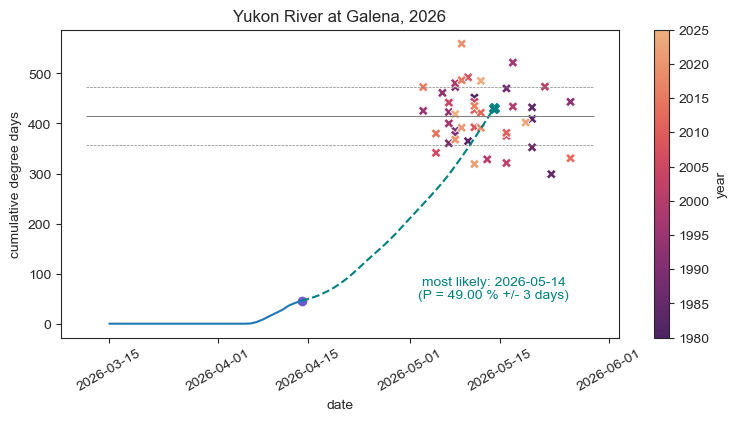

In [ ]:
theyear = str(2026)

fig = plt.subplots(figsize=(9, 4))
f = sns.lineplot(data=testdd[f'{theyear}-03-15':today], x='thedate', y=theyear, )
f2 = sns.lineplot(data=testdd[today:forecasted_date], x='thedate', y=theyear, linestyle='--', color='teal', legend=None)
g = sns.scatterplot(data=breakupdd25DF, x='thedate', y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=f, legend=None)
plt.scatter(dt.datetime.strptime(today, '%Y-%m-%d'), testdd.loc[today][theyear], color='slateblue')
plt.scatter(dt.datetime.strptime(forecasted_date, '%Y-%m-%d'), testdd.loc[forecasted_date][theyear], color='teal', s=50, marker="X")
xmin, _  = f.get_xlim()
_, xmax = g.get_xlim()
norm = plt.Normalize(breakupdd25DF['year'].min(), breakupdd25DF['year'].max())
cmap = sns.color_palette("flare_r", as_cmap=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=f, label='year')
plt.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75,)
plt.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
plt.xticks(rotation=30)
plt.xlabel('date')
plt.ylabel('cumulative degree days')
plt.title(f"{testsite}, {theyear}")
plt.text(dt.datetime.strptime(forecasted_date, '%Y-%m-%d'), 50, 
         f"most likely: {forecasted_date}\n(P = {likelihood_3d:.2f} % +/- 3 days)", color='teal', ha='center'  )
# sns.move_legend(f, "upper left")
fn = f'intermediate_cumul_{testsite.replace(' ', '_')}_{theyear}.png'
plt.savefig(fn, bbox_inches='tight')

### Loop through locations in broken_up file

Yukon River at Dawson broke up on 2025-04-30
Yukon River at Eagle broke up on 2025-05-01
Yukon River at Circle broke up on 2025-05-05
Yukon River at Fort Yukon broke up on 2025-05-06
Kuskokwim River at Nikolai broke up on 2025-04-22
Kuskokwim River at McGrath broke up on 2025-05-03
Yukon River at Galena broke up on 2025-05-08
Kuskokwim River at Crooked Creek broke up on 2025-04-28
Kuskokwim River at Sleetmute broke up on 2025-04-27
Kuskokwim River at Stony River broke up on 2025-04-27
Kuskokwim River at Red Devil broke up on 2025-04-28
Kuskokwim River at Akiak broke up on 2025-05-07
Kuskokwim River at Aniak broke up on 2025-05-01
Kuskokwim River at Kalskag broke up on 2025-05-05
Kuskokwim River at Tuluksak broke up on 2025-05-02
Kuskokwim River at Bethel broke up on 2025-05-06
Tanana River at Nenana broke up on 2025-04-27


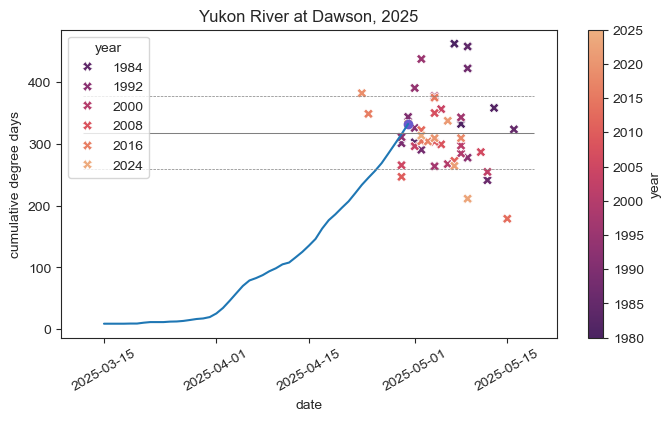

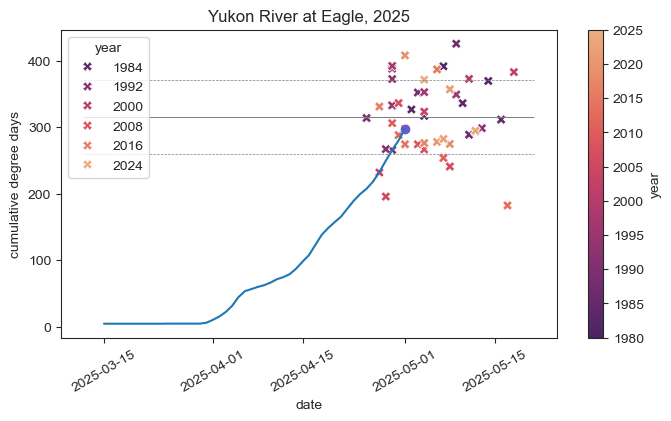

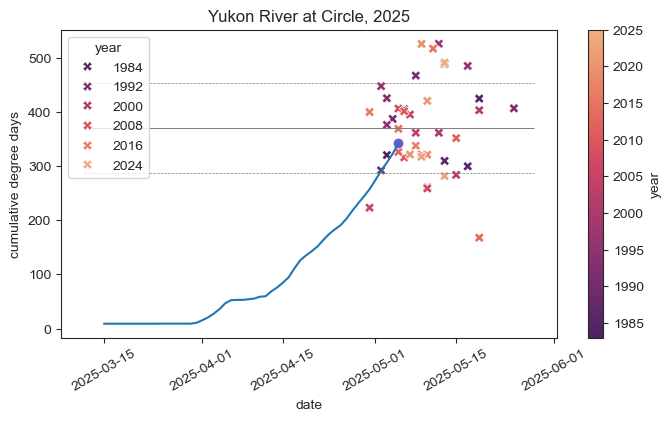

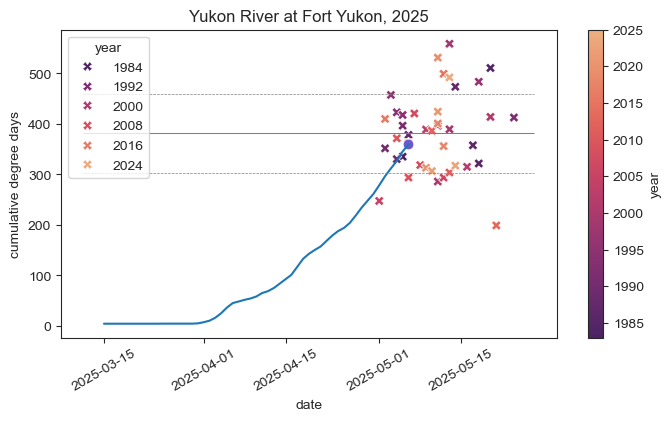

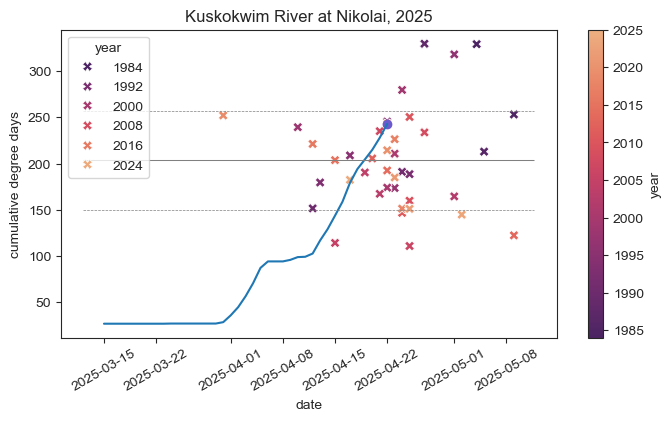

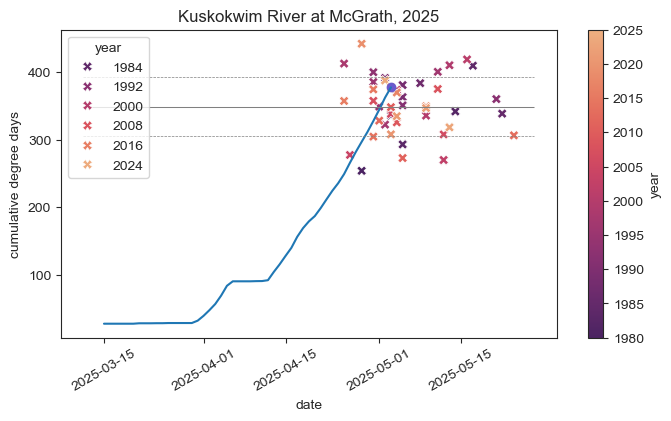

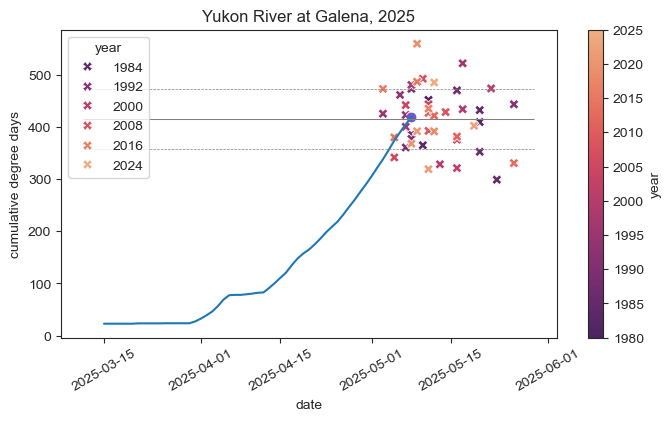

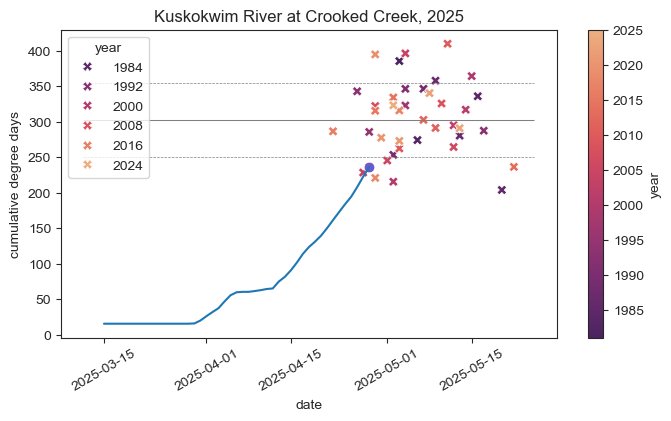

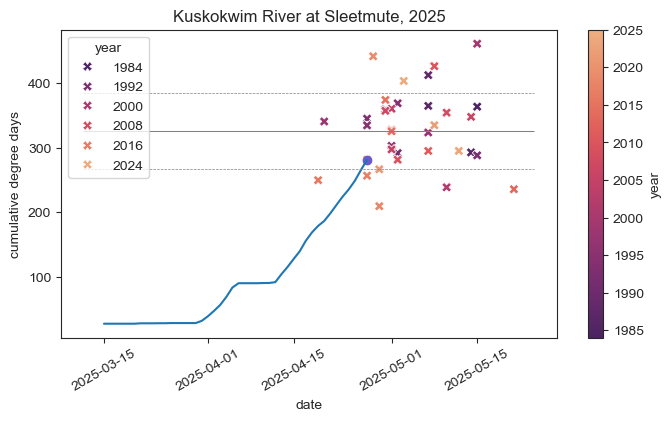

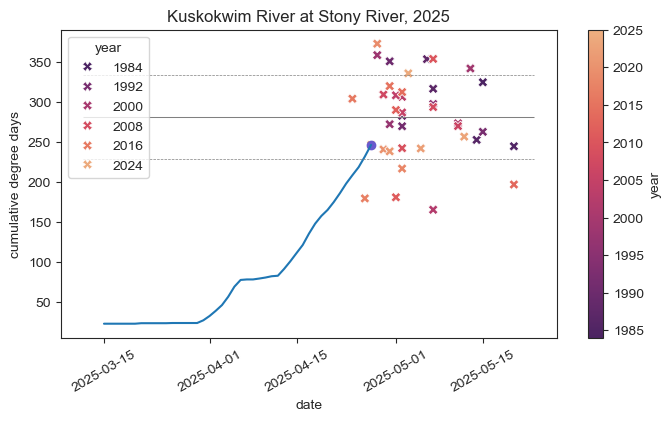

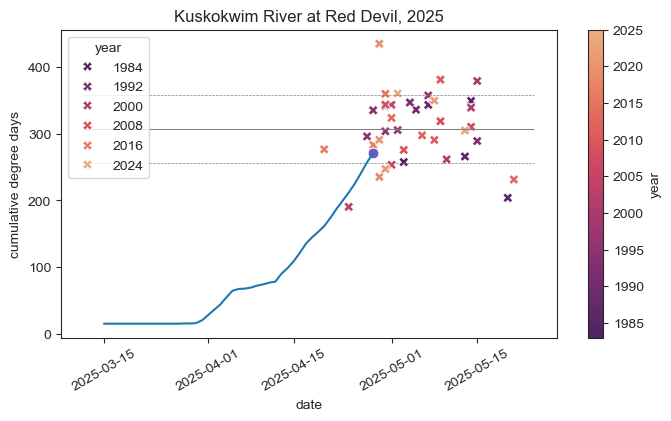

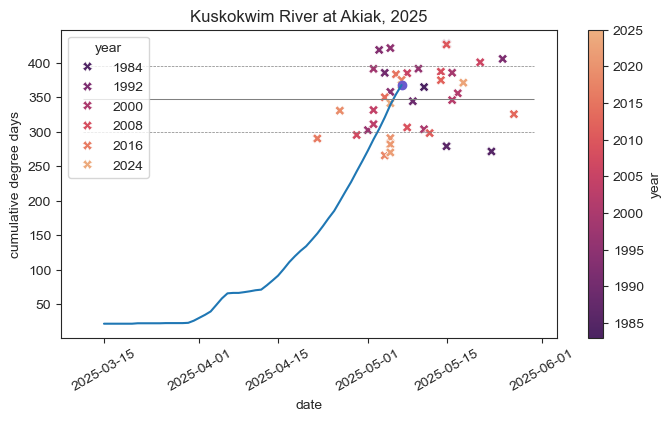

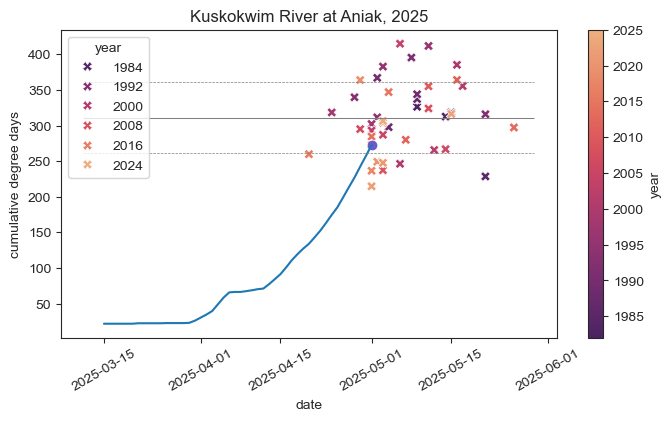

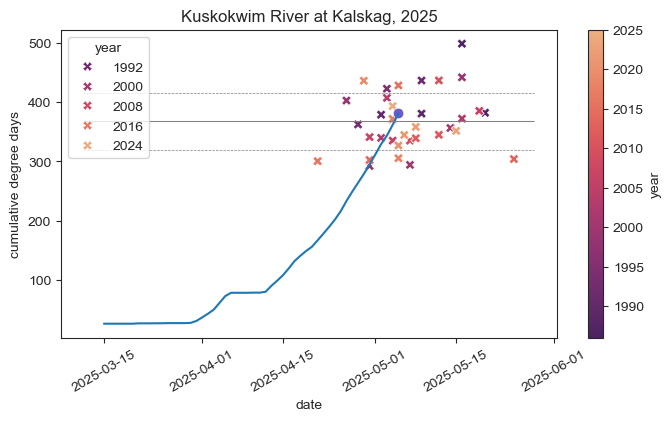

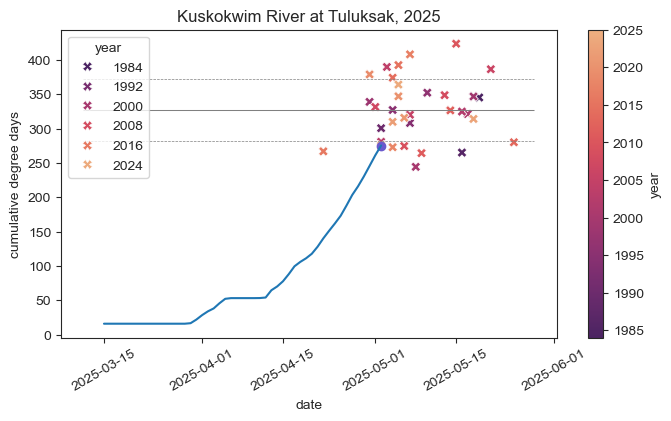

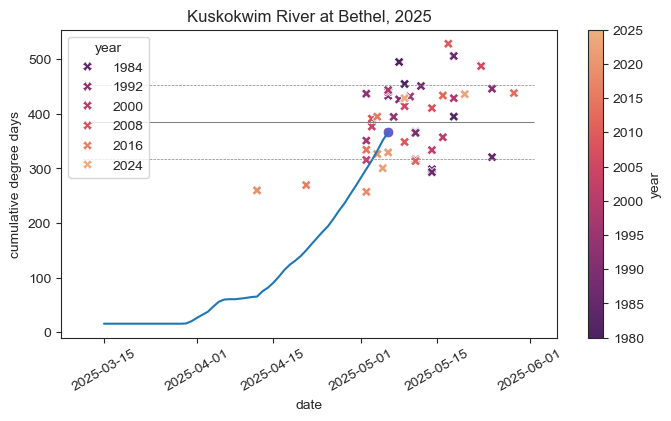

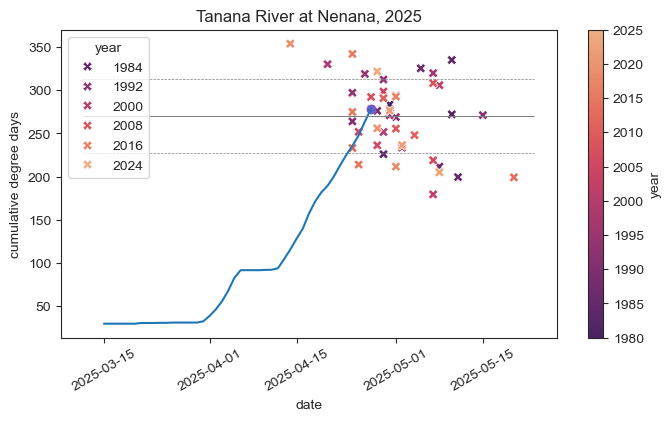

In [ ]:
theyear = str(2025)

for location, actualbreakup in broken_up.itertuples():
    print(location, "broke up on", actualbreakup)
    # load the combined DD25 averages for location
    testdd = pd.read_csv(combindedpth / f"{locationprefix}{location.replace(' ', '_')}.csv", skiprows=3)
    testdd_melted = testdd.melt(id_vars=['julian_day'], value_vars=testdd.columns[1:], var_name='year', value_name='dd25')
    testdd_melted.set_index(['julian_day', 'year'], inplace=True)
    # load historical breakupdate / DD25 values
    breakupdd25 = []
    for _, year, JulianDay in  breakup[breakup.siteID==location][['year', 'JulianDay']].itertuples():
        breakupdd25.append([year, JulianDay, testdd_melted.loc[(JulianDay, str(year)), 'dd25']])
    breakupdd25DF = pd.DataFrame(breakupdd25)
    breakupdd25DF.columns = ['year', 'JulianDay', 'DD25']
    breakupdd25DF['thedate'] = pd.to_datetime(breakupdd25DF.JulianDay-1, unit='D',
                origin=pd.Timestamp(f'{theyear}-01-01'))
    # get mean and standard deviation of historical data
    meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()
    # make a datetime index for plotting of time series
    testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
               origin=pd.Timestamp(f'{theyear}-01-01'))
    testdd.set_index('thedate', inplace=True)
    # plot and save figure 
    fig = plt.subplots(figsize=(8, 4))
    f = sns.lineplot(data=testdd[f'{theyear}-03-15':actualbreakup], x='thedate', y=theyear, )
    g = sns.scatterplot(data=breakupdd25DF, x='thedate', y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=f)
    norm = plt.Normalize(breakupdd25DF['year'].min(), breakupdd25DF['year'].max())
    cmap = sns.color_palette("flare_r", as_cmap=True)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=f, label='year')
    # sns.move_legend(f, "upper left")
    plt.scatter(dt.datetime.strptime(actualbreakup, '%Y-%m-%d'), testdd.loc[actualbreakup][theyear], color='slateblue')
    xmin, _  = f.get_xlim()
    _, xmax = g.get_xlim()
    plt.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75,)
    plt.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
    plt.xticks(rotation=30)
    plt.xlabel('date')
    plt.ylabel('cumulative degree days')
    plt.title(f"{location}, {theyear}")

    fn = f'final_cumul_{location.replace(' ', '_')}_{theyear}.png'
    plt.savefig(fn, bbox_inches='tight')
    
